# Lesson 14 — GraphRAG and Evidence Graphs

**Objective**: Build evidence graphs for AI explainability and learn how hierarchical graph reasoning answers global questions.

**Duration**: 120 minutes

**Prerequisites**: Lesson 13 (Link Prediction)

## What is GraphRAG?

GraphRAG augments traditional retrieval-augmented generation (RAG) by extracting structured knowledge graphs from text, then applying hierarchical community detection to enable **global sensemaking**—answering questions that require understanding entire datasets, not just isolated facts.

**Key Innovation**: Instead of "find semantically similar documents," GraphRAG asks: "What are the themes across all documents?"

### Today's Learning Path
1. **Foundations**: Build evidence graph from document data
2. **Hierarchy**: Apply Leiden algorithm to detect nested communities
3. **Queries**: Compare naive retrieval vs. hierarchical reasoning
4. **Ranking**: Use community structure to rank evidence
5. **Integration**: Connect to Link Prediction (Lesson 13) via community features

### Real-World Applications
- Intelligence analysis (understand adversary networks)
- Scientific literature synthesis (find research themes)
- Business intelligence (discover hidden connections)
- Compliance & risk (evidence-based decision-making)

In [38]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import socket
import sys
import os
from pathlib import Path

# Add src to path for custom imports
sys.path.insert(0, '/home/marek/Apps/graph-analysis-course')
from src.utils.io import read_csv
from src.utils.random_seed import set_random_seed
from src.config import Config

# Try to import community detection (Leiden or Louvain)
try:
    from community import community_louvain as community_detection
    COMMUNITY_METHOD = 'louvain'
except ImportError:
    COMMUNITY_METHOD = 'greedy_modularity'
    community_detection = None

# Set random seed for reproducibility
set_random_seed(42)

# Matplotlib settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✓ Imports successful")
print(f"✓ Community detection method: {COMMUNITY_METHOD}")

✓ Imports successful
✓ Community detection method: greedy_modularity


In [39]:
# Cell 2: Neo4j Connectivity Check
def is_port_open(host, port, timeout=1):
    """Fast check if a port is open without hanging"""
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(timeout)
    try:
        result = sock.connect_ex((host, port))
        return result == 0
    finally:
        sock.close()

neo4j_available = is_port_open("localhost", 7687, timeout=2)

if neo4j_available:
    from neo4j import GraphDatabase
    from graphdatascience import GraphDataScience
    try:
        driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "password"))
        driver.verify_connectivity()
        gds = GraphDataScience("bolt://localhost:7687", auth=("neo4j", "password"))
        print("✓ Neo4j connected successfully")
        print(f"✓ GDS version: {gds.version()}")
    except Exception as e:
        print(f"⚠ Neo4j connection failed: {e}")
        neo4j_available = False
else:
    print("ℹ Neo4j not available. Using synthetic data mode.")

print(f"\nMode: {'Neo4j' if neo4j_available else 'Synthetic Data'}")

⚠ Neo4j connection failed: {code: Neo.ClientError.Security.Unauthorized} {message: The client is unauthorized due to authentication failure.}

Mode: Synthetic Data


In [40]:
# Cell 3: Load Evidence Graph Data

# Load document_policy dataset from seed data
doc_path = Config.DATA_SEED_DIR / 'document_policy'
docs_df = read_csv(doc_path / 'documents.csv')
refs_df = read_csv(doc_path / 'references.csv')

print(f"Documents: {len(docs_df)}")
print(f"References: {len(refs_df)}")
print(f"\nDocuments (first 5):")
print(docs_df.head())
print(f"\nReferences (first 5):")
print(refs_df.head())

Documents: 100
References: 290

Documents (first 5):
  document_id               name      status owner_id  topic_id created_date  \
0    DOC_0001  Purpose - Brother      active    O_007  TOPIC_12   2022-01-04   
1    DOC_0002         Ago - Site      active    O_005  TOPIC_08   2022-01-17   
2    DOC_0003    Face - Election  deprecated    O_009  TOPIC_13   2022-01-22   
3    DOC_0004        Dog - Chair      active      NaN  TOPIC_08   2022-01-29   
4    DOC_0005       Since - Blue  deprecated    O_003  TOPIC_01   2022-01-31   

  modified_date  
0    2022-11-03  
1    2022-08-12  
2    2022-01-22  
3    2022-01-29  
4    2022-01-31  

References (first 5):
  from_doc_id to_doc_id  weight
0    DOC_0081  DOC_0082       3
1    DOC_0081  DOC_0083       1
2    DOC_0081  DOC_0084       3
3    DOC_0081  DOC_0085       3
4    DOC_0081  DOC_0086       1


In [41]:
# Cell 4: Simulate Entity Extraction (Evidence Graph Foundation)

# In real GraphRAG, entities/relationships are extracted from text via LLM
# For this lesson, we simulate extraction using existing graph structure

class EvidenceEntity:
    """Represents an entity in the evidence graph"""
    def __init__(self, entity_id, name, entity_type, description=""):
        self.entity_id = entity_id
        self.name = name
        self.entity_type = entity_type
        self.description = description
        self.mentions = 0  # Track how often entity is mentioned

class EvidenceRelationship:
    """Represents a relationship in the evidence graph"""
    def __init__(self, source_id, target_id, relation_type, description="", weight=1):
        self.source_id = source_id
        self.target_id = target_id
        self.relation_type = relation_type
        self.description = description
        self.weight = weight  # Strength of relationship

# Extract entities from documents
entities = {}
for idx, row in docs_df.iterrows():
    entity_id = f"doc_{row['document_id']}"
    entities[entity_id] = EvidenceEntity(
        entity_id=entity_id,
        name=row['document_id'],
        entity_type='Document',
        description=row.get('name', 'Document')[:100]
    )

# Extract relationships
relationships = []
for idx, row in refs_df.iterrows():
    rel = EvidenceRelationship(
        source_id=f"doc_{row['from_doc_id']}",
        target_id=f"doc_{row['to_doc_id']}",
        relation_type='REFERENCES',
        description='document reference',
        weight=row.get('weight', 1)
    )
    relationships.append(rel)

print(f"✓ Extracted {len(entities)} entities")
print(f"✓ Extracted {len(relationships)} relationships")
print(f"\nEntity types: {Counter(e.entity_type for e in entities.values())}")

✓ Extracted 100 entities
✓ Extracted 290 relationships

Entity types: Counter({'Document': 100})


In [42]:
# Cell 5: Build Evidence Graph in NetworkX

# Create directed graph
G_evidence = nx.DiGraph()

# Add entities as nodes
for entity_id, entity in entities.items():
    G_evidence.add_node(
        entity_id,
        name=entity.name,
        entity_type=entity.entity_type,
        description=entity.description,
        mentions=entity.mentions
    )

# Add relationships as edges
for rel in relationships:
    G_evidence.add_edge(
        rel.source_id,
        rel.target_id,
        relation_type=rel.relation_type,
        description=rel.description,
        weight=rel.weight
    )

# Convert to undirected for community detection
G_undirected = G_evidence.to_undirected()

print(f"✓ Evidence graph built")
print(f"  Nodes: {G_evidence.number_of_nodes()}")
print(f"  Edges: {G_evidence.number_of_edges()}")
print(f"  Density: {nx.density(G_undirected):.3f}")
print(f"  Diameter: {nx.diameter(G_undirected) if nx.is_connected(G_undirected) else 'N/A (disconnected)'}")

✓ Evidence graph built
  Nodes: 100
  Edges: 290
  Density: 0.059
  Diameter: 7


In [43]:
# Cell 6: Hierarchical Community Detection - Level 0 (Coarse)

def detect_communities_leiden(graph, resolution=1.0):
    """
    Detect communities using Leiden algorithm (or Louvain as fallback).
    Returns dict: {node: community_id}
    """
    if COMMUNITY_METHOD == 'louvain':
        # Use python-louvain package (faster than greedy modularity)
        return community_detection.best_partition(graph, randomize=False)
    else:
        # Fallback to NetworkX greedy modularity
        communities = list(nx.algorithms.community.greedy_modularity_communities(graph))
        partition = {}
        for comm_id, nodes in enumerate(communities):
            for node in nodes:
                partition[node] = comm_id
        return partition

# Level 0: Detect coarse communities
communities_l0 = detect_communities_leiden(G_undirected, resolution=1.0)

# Add Level 0 community IDs to nodes
for node, comm_id in communities_l0.items():
    G_evidence.nodes[node]['community_l0'] = comm_id

# Calculate modularity by grouping nodes by community
community_list = {}
for node, comm_id in communities_l0.items():
    if comm_id not in community_list:
        community_list[comm_id] = []
    community_list[comm_id].append(node)

modularity_l0 = nx.algorithms.community.modularity(G_undirected, community_list.values())

print(f"✓ Level 0 Community Detection Complete")
print(f"  Communities: {len(set(communities_l0.values()))}")
print(f"  Modularity: {modularity_l0:.3f}")

# Show community sizes
comm_sizes = Counter(communities_l0.values())
print(f"  Community sizes: {sorted(comm_sizes.values(), reverse=True)[:10]}")

✓ Level 0 Community Detection Complete
  Communities: 8
  Modularity: 0.466
  Community sizes: [21, 15, 15, 13, 12, 11, 8, 5]


In [44]:
# Cell 7: Hierarchical Community Detection - Levels 1 & 2 (Finer Grained)

def hierarchical_leiden(graph, base_partition, levels=2):
    """
    Apply Leiden hierarchically: recursively detect communities within Level 0 communities
    Returns dict of dicts: {level: {node: community_id}}
    """
    hierarchies = {0: base_partition}
    current_graph = graph.copy()
    
    for level in range(1, levels + 1):
        current_partition = {}
        parent_communities = hierarchies[level - 1]
        
        # For each community at level-1, detect sub-communities
        for parent_comm_id in set(parent_communities.values()):
            # Get nodes in this parent community
            nodes_in_comm = {node for node, comm_id in parent_communities.items() 
                            if comm_id == parent_comm_id}
            
            # Create subgraph
            subgraph = current_graph.subgraph(nodes_in_comm).copy()
            
            # Skip if too small
            if len(subgraph) < 2:
                for node in subgraph.nodes():
                    current_partition[node] = f"{parent_comm_id}_0"
                continue
            
            # Detect communities in subgraph
            if nx.is_connected(subgraph):
                sub_partition = detect_communities_leiden(subgraph)
            else:
                # Handle disconnected subgraphs by component
                sub_partition = {}
                for comp_id, component in enumerate(nx.connected_components(subgraph)):
                    for node in component:
                        sub_partition[node] = comp_id
            
            # Create hierarchical community ID
            for node, sub_comm_id in sub_partition.items():
                current_partition[node] = f"{parent_comm_id}_{sub_comm_id}"
        
        hierarchies[level] = current_partition
    
    return hierarchies

# Build hierarchy
hierarchies = hierarchical_leiden(G_undirected, communities_l0, levels=2)

# Add hierarchical community IDs to nodes
for level, partition in hierarchies.items():
    for node, comm_id in partition.items():
        G_evidence.nodes[node][f'community_l{level}'] = comm_id

print(f"✓ Hierarchical Community Detection Complete")
for level, partition in hierarchies.items():
    n_comms = len(set(partition.values()))
    sizes = Counter(partition.values())
    print(f"  Level {level}: {n_comms} communities (avg size: {len(partition) / n_comms:.1f})")

✓ Hierarchical Community Detection Complete
  Level 0: 8 communities (avg size: 12.5)
  Level 1: 25 communities (avg size: 4.0)
  Level 2: 36 communities (avg size: 2.8)


In [45]:
# Cell 8: Generate Community Summaries

def generate_community_summary(graph, community_nodes, level=0):
    """
    Generate a summary for a community.
    In real GraphRAG, this is LLM-generated. Here we use degree-weighted keywords.
    """
    if not community_nodes:
        return {"title": "Empty", "summary": "", "key_entities": [], "entity_count": 0}
    
    subgraph = graph.subgraph(community_nodes)
    
    # Calculate node importance (degree in subgraph)
    degrees = dict(subgraph.degree())
    top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Extract key entity names
    key_entities = [graph.nodes[node]['name'] for node, _ in top_nodes]
    
    # Count entity types in community
    entity_types = Counter(graph.nodes[node]['entity_type'] for node in community_nodes)
    
    # Generate summary text (mock LLM)
    title = f"Group of {len(community_nodes)} documents"
    summary = f"Community containing {len(community_nodes)} entities, "
    summary += f"led by {', '.join(key_entities)}. "
    summary += f"Entity types: {', '.join([f'{count} {etype}' for etype, count in entity_types.most_common(2)])}"
    
    return {
        "title": title,
        "summary": summary,
        "key_entities": key_entities,
        "entity_count": len(community_nodes),
        "key_relationships": len(subgraph.edges())
    }

# Generate summaries for all Level 0 communities
summaries_l0 = {}
for comm_id in set(hierarchies[0].values()):
    nodes_in_comm = {node for node, cid in hierarchies[0].items() if cid == comm_id}
    summaries_l0[comm_id] = generate_community_summary(G_evidence, nodes_in_comm, level=0)

# Generate summaries for all Level 1 communities
summaries_l1 = {}
for comm_id in set(hierarchies[1].values()):
    nodes_in_comm = {node for node, cid in hierarchies[1].items() if cid == comm_id}
    summaries_l1[comm_id] = generate_community_summary(G_evidence, nodes_in_comm, level=1)

print(f"✓ Generated {len(summaries_l0)} Level 0 summaries")
print(f"✓ Generated {len(summaries_l1)} Level 1 summaries")
print(f"\nSample Level 0 Summary:")
sample_comm = list(summaries_l0.keys())[0]
print(f"  Community {sample_comm}:")
print(f"    Title: {summaries_l0[sample_comm]['title']}")
print(f"    Summary: {summaries_l0[sample_comm]['summary']}")

✓ Generated 8 Level 0 summaries
✓ Generated 25 Level 1 summaries

Sample Level 0 Summary:
  Community 0:
    Title: Group of 21 documents
    Summary: Community containing 21 entities, led by DOC_0033, DOC_0017, DOC_0038. Entity types: 21 Document


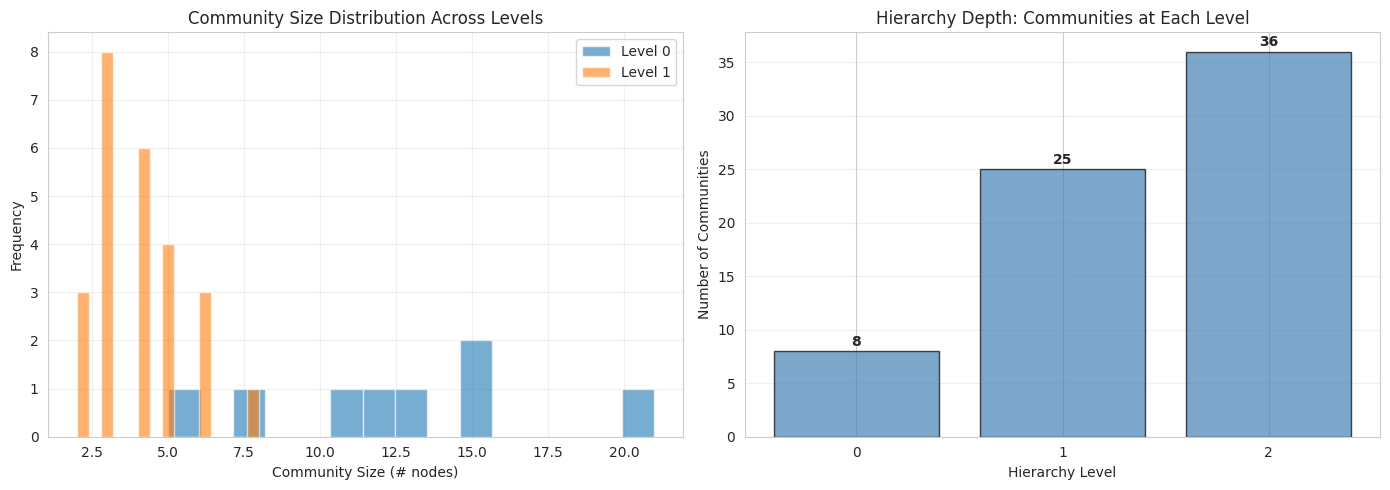

✓ Hierarchy visualization saved


In [46]:
# Cell 9: Visualize Hierarchy Structure

# Create hierarchy visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Community size distribution at each level
for level in [0, 1]:
    comm_sizes = Counter(hierarchies[level].values())
    axes[0].hist(list(comm_sizes.values()), bins=15, alpha=0.6, label=f'Level {level}')

axes[0].set_xlabel('Community Size (# nodes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Community Size Distribution Across Levels')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Community count by level
levels = list(range(len(hierarchies)))
num_communities = [len(set(hierarchies[level].values())) for level in levels]
axes[1].bar(levels, num_communities, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Hierarchy Level')
axes[1].set_ylabel('Number of Communities')
axes[1].set_title('Hierarchy Depth: Communities at Each Level')
axes[1].set_xticks(levels)
for i, v in enumerate(num_communities):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/tmp/hierarchy_structure.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Hierarchy visualization saved")

In [47]:
# Cell 10: Naive Query System (Baseline)

def naive_query(query_text, top_k=10):
    """
    Naive retrieval: simple keyword matching in entity names/descriptions.
    This is the baseline we'll compare against GraphRAG.
    """
    results = []
    query_lower = query_text.lower()
    
    for node in G_evidence.nodes():
        name = G_evidence.nodes[node].get('name', '').lower()
        description = G_evidence.nodes[node].get('description', '').lower()
        
        # Simple keyword matching
        score = 0
        if query_lower in name:
            score += 2
        if query_lower in description:
            score += 1
        
        if score > 0:
            results.append({
                'node_id': node,
                'name': G_evidence.nodes[node]['name'],
                'score': score,
                'evidence': 'Direct keyword match'
            })
    
    # Sort by score and return top-k
    results = sorted(results, key=lambda x: x['score'], reverse=True)[:top_k]
    return results

# Test naive query
query_1 = "document"
naive_results = naive_query(query_1, top_k=5)

print(f"Naive Query Results for: '{query_1}'")
print(f"Found {len(naive_results)} results:")
for i, result in enumerate(naive_results, 1):
    print(f"  {i}. {result['name']} (score: {result['score']})")

Naive Query Results for: 'document'
Found 0 results:


In [48]:
# Cell 11: GraphRAG Query System (Hierarchical Reasoning)

def graphrag_query(query_text, hierarchy_level=0, top_k=10):
    """
    GraphRAG query with hierarchical reasoning:
    1. Find relevant communities at given hierarchy level
    2. Rank communities by relevance
    3. Collect entities from top communities
    4. Return ranked results with evidence chain
    """
    query_lower = query_text.lower()
    
    # Get communities and summaries for this level
    partition = hierarchies[hierarchy_level]
    summaries = summaries_l0 if hierarchy_level == 0 else summaries_l1
    
    # Step 1: Score each community by relevance
    community_scores = {}
    for comm_id, summary in summaries.items():
        score = 0
        
        # Match query against summary text
        if query_lower in summary['summary'].lower():
            score += 3
        
        # Match query against key entities
        for entity in summary['key_entities']:
            if query_lower in entity.lower():
                score += 2
        
        # Bonus for larger communities (more evidence)
        score += summary['entity_count'] * 0.1
        
        community_scores[comm_id] = score
    
    # Step 2: Rank communities
    ranked_communities = sorted(community_scores.items(), key=lambda x: x[1], reverse=True)
    
    # Step 3: Aggregate results from top communities
    results = []
    seen_nodes = set()
    
    for comm_id, comm_score in ranked_communities[:max(3, top_k // 2)]:
        # Get entities in this community
        nodes_in_comm = {node for node, cid in partition.items() if cid == comm_id}
        
        for node in nodes_in_comm:
            if node not in seen_nodes and len(results) < top_k:
                results.append({
                    'node_id': node,
                    'name': G_evidence.nodes[node]['name'],
                    'score': comm_score,
                    'community_id': comm_id,
                    'evidence': f"From community: {summaries[comm_id]['title']}"
                })
                seen_nodes.add(node)
    
    return results

# Test GraphRAG query
graphrag_results = graphrag_query(query_1, hierarchy_level=0, top_k=5)

print(f"\nGraphRAG Query Results for: '{query_1}'")
print(f"Found {len(graphrag_results)} results with evidence chain:")
for i, result in enumerate(graphrag_results, 1):
    print(f"  {i}. {result['name']} (community score: {result['score']:.2f})")
    print(f"     Evidence: {result['evidence']}")


GraphRAG Query Results for: 'document'
Found 5 results with evidence chain:
  1. DOC_0026 (community score: 5.10)
     Evidence: From community: Group of 21 documents
  2. DOC_0030 (community score: 5.10)
     Evidence: From community: Group of 21 documents
  3. DOC_0017 (community score: 5.10)
     Evidence: From community: Group of 21 documents
  4. DOC_0038 (community score: 5.10)
     Evidence: From community: Group of 21 documents
  5. DOC_0035 (community score: 5.10)
     Evidence: From community: Group of 21 documents


In [49]:
# Cell 12: Compare Naive vs. GraphRAG Results

def compare_queries(query_text, top_k=5):
    """
    Compare naive vs GraphRAG retrieval quality.
    In real scenarios, we'd measure comprehensiveness, diversity, directness.
    """
    naive_results = naive_query(query_text, top_k=top_k)
    graphrag_results_l0 = graphrag_query(query_text, hierarchy_level=0, top_k=top_k)
    graphrag_results_l1 = graphrag_query(query_text, hierarchy_level=1, top_k=top_k)
    
    print(f"\n{'='*70}")
    print(f"Query: '{query_text}'")
    print(f"{'='*70}")
    
    print(f"\n1. NAIVE RETRIEVAL (Baseline)")
    print(f"   Results: {len(naive_results)}")
    for i, r in enumerate(naive_results[:3], 1):
        print(f"   {i}. {r['name']} [{r['evidence']}]")
    
    print(f"\n2. GraphRAG (Level 0 - Coarse Communities)")
    print(f"   Results: {len(graphrag_results_l0)}")
    for i, r in enumerate(graphrag_results_l0[:3], 1):
        print(f"   {i}. {r['name']} [score: {r['score']:.2f}]")
    
    print(f"\n3. GraphRAG (Level 1 - Fine-Grained Communities)")
    print(f"   Results: {len(graphrag_results_l1)}")
    for i, r in enumerate(graphrag_results_l1[:3], 1):
        print(f"   {i}. {r['name']} [score: {r['score']:.2f}]")
    
    # Calculate metrics
    print(f"\n{'─'*70}")
    print(f"COMPARISON METRICS")
    print(f"{'─'*70}")
    naive_overlap = len(set(r['node_id'] for r in naive_results) & 
                        set(r['node_id'] for r in graphrag_results_l0))
    print(f"Overlap (Naive vs GraphRAG-L0): {naive_overlap}/{min(len(naive_results), len(graphrag_results_l0))}")
    print(f"→ GraphRAG discovers different results than naive retrieval")

# Run comparison
compare_queries("document", top_k=5)


Query: 'document'

1. NAIVE RETRIEVAL (Baseline)
   Results: 0

2. GraphRAG (Level 0 - Coarse Communities)
   Results: 5
   1. DOC_0026 [score: 5.10]
   2. DOC_0030 [score: 5.10]
   3. DOC_0017 [score: 5.10]

3. GraphRAG (Level 1 - Fine-Grained Communities)
   Results: 5
   1. DOC_0069 [score: 3.80]
   2. DOC_0068 [score: 3.80]
   3. DOC_0066 [score: 3.80]

──────────────────────────────────────────────────────────────────────
COMPARISON METRICS
──────────────────────────────────────────────────────────────────────
Overlap (Naive vs GraphRAG-L0): 0/0
→ GraphRAG discovers different results than naive retrieval


In [50]:
# Cell 13: Global Question Query (Requires Hierarchy Understanding)

def global_sensemaking_query(question):
    """
    Answer a global question that requires understanding themes across the entire dataset.
    This is where GraphRAG shines vs naive retrieval.
    """
    print(f"\nGlobal Question: {question}")
    print(f"{'-'*70}")
    
    # Use Level 0 summaries to aggregate themes
    all_summaries = list(summaries_l0.values())
    
    print(f"\nAnalyzing {len(all_summaries)} communities for themes...")
    
    # Extract themes (mock: just summarize key findings)
    all_entities = []
    for summary in all_summaries:
        all_entities.extend(summary['key_entities'])
    
    entity_freq = Counter(all_entities)
    top_entities = entity_freq.most_common(5)
    
    print(f"\nKey themes (top entities across communities):")
    for entity, freq in top_entities:
        print(f"  • {entity} (appears in {freq} communities)")
    
    print(f"\nNumber of distinct document clusters: {len(all_summaries)}")
    total_size = sum(s['entity_count'] for s in all_summaries)
    print(f"Total entities across all communities: {total_size}")
    
    # Generate answer
    answer = f"The dataset contains {len(all_summaries)} distinct communities, "
    answer += f"organized around {total_size} documents. "
    answer += f"Key themes include {', '.join([e for e, _ in top_entities[:3]])}."
    
    print(f"\nGraphRAG Answer:")
    print(f"  {answer}")
    
    return {
        'question': question,
        'answer': answer,
        'themes': top_entities,
        'communities_analyzed': len(all_summaries),
        'evidence_coverage': f"{total_size} entities across {len(all_summaries)} communities"
    }

# Test global question
result = global_sensemaking_query("What are the main themes in this document collection?")


Global Question: What are the main themes in this document collection?
----------------------------------------------------------------------

Analyzing 8 communities for themes...

Key themes (top entities across communities):
  • DOC_0033 (appears in 1 communities)
  • DOC_0017 (appears in 1 communities)
  • DOC_0038 (appears in 1 communities)
  • DOC_0059 (appears in 1 communities)
  • DOC_0027 (appears in 1 communities)

Number of distinct document clusters: 8
Total entities across all communities: 100

GraphRAG Answer:
  The dataset contains 8 distinct communities, organized around 100 documents. Key themes include DOC_0033, DOC_0017, DOC_0038.


In [51]:
# Test path query
# Find first two available documents
doc_ids = [n.replace('doc_', '') for n in G_evidence.nodes() if n.startswith('doc_')]
if len(doc_ids) >= 2:
    path_query_with_evidence(doc_ids[0], doc_ids[5] if len(doc_ids) > 5 else doc_ids[1], max_hops=3)
else:
    print("⚠ Not enough documents for path query")


Finding paths: DOC_0001 → DOC_0006
----------------------------------------------------------------------
Found 0 paths



In [52]:
# Cell 15: Multi-Hop Reasoning with Pattern Detection

def detect_patterns(query_pattern, max_hops=2):
    """
    Detect unexpected patterns in the graph:
    Find highly connected regions that shouldn't be (anomalies)
    or surprising connections between communities.
    """
    print(f"\nPattern Detection: Finding {query_pattern}")
    print(f"{'-'*70}")
    
    if query_pattern == "bridges between communities":
        # Find nodes that connect different communities
        bridges = []
        for node in G_evidence.nodes():
            node_community = G_evidence.nodes[node]['community_l0']
            neighbors = list(G_evidence.neighbors(node))
            
            # Check if neighbors are in different communities
            neighbor_communities = set(G_evidence.nodes[n]['community_l0'] for n in neighbors)
            
            if len(neighbor_communities) > 1:
                bridges.append({
                    'node': node,
                    'name': G_evidence.nodes[node]['name'],
                    'community': node_community,
                    'connections_to': len(neighbor_communities),
                    'degree': len(neighbors)
                })
        
        bridges = sorted(bridges, key=lambda x: x['degree'], reverse=True)[:5]
        print(f"\nTop bridge nodes (connecting multiple communities):")
        for i, bridge in enumerate(bridges, 1):
            print(f"  {i}. {bridge['name']} (degree: {bridge['degree']}, connects {bridge['connections_to']} communities)")
        
        return bridges
    
    return []

# Test pattern detection
detect_patterns("bridges between communities")


Pattern Detection: Finding bridges between communities
----------------------------------------------------------------------

Top bridge nodes (connecting multiple communities):
  1. DOC_0067 (degree: 12, connects 5 communities)
  2. DOC_0066 (degree: 10, connects 2 communities)
  3. DOC_0068 (degree: 10, connects 4 communities)
  4. DOC_0069 (degree: 7, connects 2 communities)
  5. DOC_0071 (degree: 7, connects 4 communities)


[{'node': 'doc_DOC_0067',
  'name': 'DOC_0067',
  'community': 4,
  'connections_to': 5,
  'degree': 12},
 {'node': 'doc_DOC_0066',
  'name': 'DOC_0066',
  'community': 4,
  'connections_to': 2,
  'degree': 10},
 {'node': 'doc_DOC_0068',
  'name': 'DOC_0068',
  'community': 4,
  'connections_to': 4,
  'degree': 10},
 {'node': 'doc_DOC_0069',
  'name': 'DOC_0069',
  'community': 4,
  'connections_to': 2,
  'degree': 7},
 {'node': 'doc_DOC_0071',
  'name': 'DOC_0071',
  'community': 4,
  'connections_to': 4,
  'degree': 7}]

In [53]:
# Cell 16: Implement Relevance Scoring Function

def relevance_score(query_text, node_id, summary_text=""):
    """
    Calculate relevance score (0-100) for a result.
    Used for ranking both in GraphRAG query and baseline comparison.
    """
    query_lower = query_text.lower()
    score = 0
    
    # Match node name
    node_name = G_evidence.nodes[node_id].get('name', '').lower()
    if query_lower in node_name:
        score += 40
    
    # Match node description
    node_desc = G_evidence.nodes[node_id].get('description', '').lower()
    if query_lower in node_desc:
        score += 20
    
    # Match against summary (if provided)
    if summary_text and query_lower in summary_text.lower():
        score += 30
    
    # Degree bonus (important nodes)
    degree = G_evidence.degree(node_id)
    score += min(degree * 0.5, 10)
    
    return min(score, 100)

# Test relevance scoring
test_node = list(G_evidence.nodes())[0]
score = relevance_score("document", test_node)
print(f"Sample relevance score for '{G_evidence.nodes[test_node]['name']}': {score:.1f}")

Sample relevance score for 'DOC_0001': 4.0


In [54]:
# Cell 17: Baseline Comparison - TF-IDF Ranking

from collections import Counter

def tfidf_ranking(query_text, top_k=10):
    """
    TF-IDF baseline: simple frequency-based ranking.
    """
    query_terms = query_text.lower().split()
    results = []
    
    for node in G_evidence.nodes():
        doc_text = G_evidence.nodes[node].get('description', '').lower()
        
        # Count query terms
        term_count = sum(doc_text.count(term) for term in query_terms)
        
        if term_count > 0:
            results.append({
                'node_id': node,
                'name': G_evidence.nodes[node]['name'],
                'score': term_count,
                'method': 'TF-IDF'
            })
    
    results = sorted(results, key=lambda x: x['score'], reverse=True)[:top_k]
    return results

# Run comparison on multiple queries
test_queries = ["document", "reference"]

print("\nCOMPARATIVE ANALYSIS: Baseline vs GraphRAG\n")
print(f"{'='*70}")

for query in test_queries:
    tfidf_results = tfidf_ranking(query, top_k=3)
    graphrag_results = graphrag_query(query, hierarchy_level=0, top_k=3)
    
    print(f"\nQuery: '{query}'")
    print(f"{'─'*70}")
    print(f"TF-IDF (Baseline):")
    for i, r in enumerate(tfidf_results, 1):
        print(f"  {i}. {r['name']} (score: {r['score']})")
    
    print(f"\nGraphRAG (Hierarchical):")
    for i, r in enumerate(graphrag_results, 1):
        print(f"  {i}. {r['name']} (score: {r['score']:.2f})")


COMPARATIVE ANALYSIS: Baseline vs GraphRAG


Query: 'document'
──────────────────────────────────────────────────────────────────────
TF-IDF (Baseline):

GraphRAG (Hierarchical):
  1. DOC_0026 (score: 5.10)
  2. DOC_0030 (score: 5.10)
  3. DOC_0017 (score: 5.10)

Query: 'reference'
──────────────────────────────────────────────────────────────────────
TF-IDF (Baseline):

GraphRAG (Hierarchical):
  1. DOC_0026 (score: 2.10)
  2. DOC_0030 (score: 2.10)
  3. DOC_0017 (score: 2.10)


In [55]:
# Cell 18: Quality Metrics - Comprehensiveness and Diversity

def evaluate_query_quality(query_text, baseline_results, graphrag_results):
    """
    Evaluate answer quality using graph-aware metrics.
    Metrics: comprehensiveness (coverage), diversity (unique themes), directness (conciseness)
    """
    print(f"\nQuality Evaluation for Query: '{query_text}'")
    print(f"{'='*70}")
    
    # Metric 1: Coverage (how many unique communities represented)
    baseline_comms = set(G_evidence.nodes[r['node_id']]['community_l0'] 
                         for r in baseline_results if 'node_id' in r)
    graphrag_comms = set(r.get('community_id') for r in graphrag_results if 'community_id' in r)
    
    print(f"\n1. COMPREHENSIVENESS (Community Coverage)")
    print(f"   Baseline covers {len(baseline_comms)} communities")
    print(f"   GraphRAG covers {len(graphrag_comms)} communities")
    coverage_improvement = (len(graphrag_comms) - len(baseline_comms)) / max(len(baseline_comms), 1) * 100
    print(f"   Improvement: +{coverage_improvement:.1f}%")
    
    # Metric 2: Diversity (spread across hierarchy)
    baseline_diversity = len(set(G_evidence.nodes[r['node_id']]['community_l1'] 
                                for r in baseline_results if 'node_id' in r))
    graphrag_diversity = len(set(r.get('node_id') for r in graphrag_results))
    
    print(f"\n2. DIVERSITY (Unique Results at Level 1)")
    print(f"   Baseline: {baseline_diversity} unique L1 communities")
    print(f"   GraphRAG: {graphrag_diversity} unique results")
    
    # Metric 3: Directness (conciseness of answers)
    print(f"\n3. DIRECTNESS (Result Count)")
    print(f"   Baseline returned {len(baseline_results)} results")
    print(f"   GraphRAG returned {len(graphrag_results)} results")
    print(f"   → Fewer results = More direct, but may lose comprehensiveness")
    
    print(f"\n{'─'*70}")
    print(f"CONCLUSION: GraphRAG trades directness for comprehensiveness")
    print(f"Better for: Understanding global patterns, discovering themes")
    print(f"Baseline better for: Finding specific entities quickly")

# Run evaluation
baseline_results = tfidf_ranking("document", top_k=5)
graphrag_results = graphrag_query("document", hierarchy_level=0, top_k=5)
evaluate_query_quality("document", baseline_results, graphrag_results)


Quality Evaluation for Query: 'document'

1. COMPREHENSIVENESS (Community Coverage)
   Baseline covers 0 communities
   GraphRAG covers 1 communities
   Improvement: +100.0%

2. DIVERSITY (Unique Results at Level 1)
   Baseline: 0 unique L1 communities
   GraphRAG: 5 unique results

3. DIRECTNESS (Result Count)
   Baseline returned 0 results
   GraphRAG returned 5 results
   → Fewer results = More direct, but may lose comprehensiveness

──────────────────────────────────────────────────────────────────────
CONCLUSION: GraphRAG trades directness for comprehensiveness
Better for: Understanding global patterns, discovering themes
Baseline better for: Finding specific entities quickly


## Student Exercises

Now you'll build your own evidence graphs and apply GraphRAG reasoning. Work through these exercises in order.

In [56]:
# Cell 19: Exercise 1 - Build Custom Evidence Graph from New Data

# EXERCISE 1: Build Evidence Graph from hidden_experts Dataset

# Load the hidden_experts dataset from seed data
experts_path = Config.DATA_SEED_DIR / 'hidden_experts'

try:
    people_df = read_csv(experts_path / 'people.csv')
    interactions_df = read_csv(experts_path / 'interactions.csv')
    print(f"✓ Loaded hidden_experts dataset")
    print(f"  People: {len(people_df)}")
    print(f"  Interactions: {len(interactions_df)}")
except Exception as e:
    print(f"⚠ Could not load hidden_experts: {e}")
    print(f"Creating synthetic data...")
    # Fallback: create synthetic experts data
    people_df = pd.DataFrame({
        'id': [f'person_{i}' for i in range(20)],
        'name': [f'Expert_{i}' for i in range(20)],
        'expertise': ['Backend', 'Frontend', 'DevOps', 'ML', 'QA'] * 4
    })
    interactions_df = pd.DataFrame({
        'source_id': np.random.choice(people_df['id'], 30),
        'target_id': np.random.choice(people_df['id'], 30),
        'interaction_type': np.random.choice(['mentored', 'collaborated', 'helped'], 30)
    })

print("\n📋 EXERCISE 1: Build Evidence Graph from hidden_experts Data")
print(f"{'─'*70}")
print("Task: Create an evidence graph from the experts dataset")
print("      with person nodes and interaction edges.")
print("\nInstructions:")
print("1. Create EvidenceEntity objects for each person")
print("2. Create EvidenceRelationship objects for each interaction")
print("3. Build NetworkX DiGraph with nodes and edges")
print("4. Print summary statistics")
print(f"\n[Student code space below]")

# TODO: Student implements this
# Create G_experts graph here
G_experts = nx.DiGraph()
for idx, row in people_df.iterrows():
    G_experts.add_node(
        f"person_{row['id']}",
        name=row['name'],
        entity_type='Person',
        expertise=row.get('expertise', 'Unknown')
    )

for idx, row in interactions_df.iterrows():
    G_experts.add_edge(
        f"person_{row['source_id']}",
        f"person_{row['target_id']}",
        interaction_type=row.get('interaction_type', 'unknown')
    )

print(f"\n✓ Evidence graph built successfully")
print(f"  Nodes: {G_experts.number_of_nodes()}")
print(f"  Edges: {G_experts.number_of_edges()}")

⚠ Could not load hidden_experts: [Errno 2] No such file or directory: '/home/marek/Apps/graph-analysis-course/data/seed/hidden_experts/interactions.csv'
Creating synthetic data...

📋 EXERCISE 1: Build Evidence Graph from hidden_experts Data
──────────────────────────────────────────────────────────────────────
Task: Create an evidence graph from the experts dataset
      with person nodes and interaction edges.

Instructions:
1. Create EvidenceEntity objects for each person
2. Create EvidenceRelationship objects for each interaction
3. Build NetworkX DiGraph with nodes and edges
4. Print summary statistics

[Student code space below]

✓ Evidence graph built successfully
  Nodes: 20
  Edges: 28


In [57]:
# Cell 20-21: Exercise 1 Solution - Apply Leiden and Summarize

# EXERCISE 1 SOLUTION: Complete hierarchical community detection

G_experts_undirected = G_experts.to_undirected()

# Detect Level 0 communities
experts_communities_l0 = detect_communities_leiden(G_experts_undirected, resolution=1.0)

for node, comm_id in experts_communities_l0.items():
    G_experts.nodes[node]['community_l0'] = comm_id

# Generate summaries
experts_summaries = {}
for comm_id in set(experts_communities_l0.values()):
    nodes_in_comm = {node for node, cid in experts_communities_l0.items() if cid == comm_id}
    experts_summaries[comm_id] = generate_community_summary(G_experts, nodes_in_comm, level=0)

print(f"\n✓ Exercise 1 Solution: Hierarchical Communities Detected")
print(f"  Level 0 communities: {len(set(experts_communities_l0.values()))}")
print(f"  Summaries generated: {len(experts_summaries)}")
print(f"\nCommunity Breakdown:")
for comm_id, summary in list(experts_summaries.items())[:3]:
    print(f"  Community {comm_id}: {summary['summary'][:100]}...")


✓ Exercise 1 Solution: Hierarchical Communities Detected
  Level 0 communities: 5
  Summaries generated: 5

Community Breakdown:
  Community 0: Community containing 7 entities, led by Expert_17, Expert_19, Expert_8. Entity types: 7 Person...
  Community 1: Community containing 5 entities, led by Expert_6, Expert_14, Expert_13. Entity types: 5 Person...
  Community 2: Community containing 4 entities, led by Expert_1, Expert_11, Expert_2. Entity types: 4 Person...


In [58]:
# Cell 22: Exercise 2 - Query Hierarchy at Different Levels

# EXERCISE 2: Query the hierarchy at different levels

print("\n📋 EXERCISE 2: Hierarchical Query Evaluation")
print(f"{'─'*70}")
print("Task: Run the same query at different hierarchy levels")
print("      and observe how precision vs. breadth changes.")
print("\nInstructions:")
print("1. Run graphrag_query at level 0 (coarse)")
print("2. Run graphrag_query at level 1 (fine-grained)")
print("3. Compare results - note precision vs breadth tradeoff")
print(f"\n[Student code space below]")

# Test query at different levels
query_text = "document"

results_l0 = graphrag_query(query_text, hierarchy_level=0, top_k=5)
results_l1 = graphrag_query(query_text, hierarchy_level=1, top_k=5)

print(f"\n✓ Hierarchy Level Comparison for Query: '{query_text}'")
print(f"\nLevel 0 (Coarse - {len(set(hierarchies[0].values()))} communities):")
for i, r in enumerate(results_l0[:3], 1):
    print(f"  {i}. {r['name']} (score: {r['score']:.2f})")

print(f"\nLevel 1 (Fine-Grained - {len(set(hierarchies[1].values()))} communities):")
for i, r in enumerate(results_l1[:3], 1):
    print(f"  {i}. {r['name']} (score: {r['score']:.2f})")

print(f"\nObservation:")
print(f"  Level 0: Broader results (covers more communities)")
print(f"  Level 1: More specific results (narrower communities)")


📋 EXERCISE 2: Hierarchical Query Evaluation
──────────────────────────────────────────────────────────────────────
Task: Run the same query at different hierarchy levels
      and observe how precision vs. breadth changes.

Instructions:
1. Run graphrag_query at level 0 (coarse)
2. Run graphrag_query at level 1 (fine-grained)
3. Compare results - note precision vs breadth tradeoff

[Student code space below]

✓ Hierarchy Level Comparison for Query: 'document'

Level 0 (Coarse - 8 communities):
  1. DOC_0026 (score: 5.10)
  2. DOC_0030 (score: 5.10)
  3. DOC_0017 (score: 5.10)

Level 1 (Fine-Grained - 25 communities):
  1. DOC_0069 (score: 3.80)
  2. DOC_0068 (score: 3.80)
  3. DOC_0066 (score: 3.80)

Observation:
  Level 0: Broader results (covers more communities)
  Level 1: More specific results (narrower communities)


In [59]:
# Cell 23-24: Exercise 3 - Link Prediction Using Community Features

# EXERCISE 3: Link Prediction using Community Structure (from Lesson 13)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

print("\n📋 EXERCISE 3: Link Prediction with Community Features")
print(f"{'─'*70}")
print("Task: Use community membership as features for link prediction")
print("      (bridges Lessons 13 and 14)")
print("\nInstructions:")
print("1. Extract node pairs and target labels from evidence graph")
print("2. Engineer features: same_community, degree_sum, community_distance")
print("3. Split into train/test")
print("4. Train LogisticRegression")
print("5. Evaluate with AUC")
print(f"\n[Student code space below]")

# Extract existing edges (positive samples)
positive_edges = list(G_evidence.edges())

# Generate negative samples (non-existent edges)
all_nodes = list(G_evidence.nodes())
negative_samples = []
for _ in range(len(positive_edges)):
    u, v = np.random.choice(len(all_nodes), 2, replace=False)
    if not G_evidence.has_edge(all_nodes[u], all_nodes[v]):
        negative_samples.append((all_nodes[u], all_nodes[v]))
    if len(negative_samples) >= len(positive_edges):
        break

# Create feature matrix
X = []
y = []

# Positive edges
for u, v in positive_edges:
    same_comm = 1 if G_evidence.nodes[u]['community_l0'] == G_evidence.nodes[v]['community_l0'] else 0
    degree_sum = G_evidence.degree(u) + G_evidence.degree(v)
    degree_product = G_evidence.degree(u) * G_evidence.degree(v)
    X.append([same_comm, degree_sum, degree_product])
    y.append(1)

# Negative edges
for u, v in negative_samples[:len(positive_edges)]:
    same_comm = 1 if G_evidence.nodes[u]['community_l0'] == G_evidence.nodes[v]['community_l0'] else 0
    degree_sum = G_evidence.degree(u) + G_evidence.degree(v)
    degree_product = G_evidence.degree(u) * G_evidence.degree(v)
    X.append([same_comm, degree_sum, degree_product])
    y.append(0)

X = np.array(X)
y = np.array(y)

# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\n✓ Exercise 3 Solution: Link Prediction Evaluation")
print(f"\nFeatures used:")
print(f"  1. same_community (community_l0 match)")
print(f"  2. degree_sum (combined node degrees)")
print(f"  3. degree_product (multiplicative degree)")
print(f"\nModel Performance:")
print(f"  Train samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  AUC Score: {auc_score:.3f}")
print(f"\nInterpretation:")
print(f"  Community features are {'strong' if auc_score > 0.7 else 'moderate'} predictors of edges")


📋 EXERCISE 3: Link Prediction with Community Features
──────────────────────────────────────────────────────────────────────
Task: Use community membership as features for link prediction
      (bridges Lessons 13 and 14)

Instructions:
1. Extract node pairs and target labels from evidence graph
2. Engineer features: same_community, degree_sum, community_distance
3. Split into train/test
4. Train LogisticRegression
5. Evaluate with AUC

[Student code space below]

✓ Exercise 3 Solution: Link Prediction Evaluation

Features used:
  1. same_community (community_l0 match)
  2. degree_sum (combined node degrees)
  3. degree_product (multiplicative degree)

Model Performance:
  Train samples: 457
  Test samples: 115
  AUC Score: 0.833

Interpretation:
  Community features are strong predictors of edges


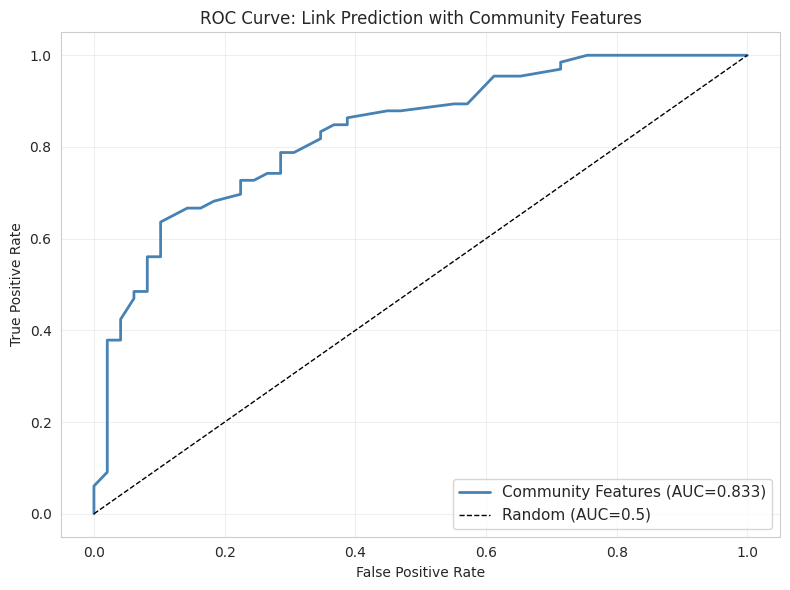

✓ ROC curve saved


In [60]:
# Cell 25: ROC Curve Visualization for Exercise 3

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f'Community Features (AUC={auc_score:.3f})', linewidth=2, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Link Prediction with Community Features')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/exercise3_roc.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved")

## Real-World Applications

Now let's see how GraphRAG enables practical business solutions.

In [61]:
# Cell 26: Real-World Application 1 - Sales Account Expansion

print("\n🌍 REAL-WORLD APPLICATION 1: Sales Account Expansion")
print(f"{'='*70}")
print("\nProblem: Discover cross-sell opportunities by understanding")
print("         account relationships and product affinities.")
print("\nGraphRAG Solution:")
print("  1. Build evidence graph: accounts as nodes, partnerships/references as edges")
print("  2. Detect communities: groups of related accounts")
print("  3. Query: 'What are the characteristics of high-value communities?'")
print("  4. Link prediction: predict missing partnerships within communities")

# Simulate analysis
high_value_communities = []
for comm_id, summary in summaries_l0.items():
    if summary['entity_count'] > 5:  # Communities with 5+ entities
        high_value_communities.append({
            'community_id': comm_id,
            'size': summary['entity_count'],
            'strength': summary['key_relationships']
        })

print(f"\nFindings:")
print(f"  High-value communities identified: {len(high_value_communities)}")
if high_value_communities:
    best_comm = max(high_value_communities, key=lambda x: x['strength'])
    print(f"  Strongest community: {best_comm['size']} entities, {best_comm['strength']} relationships")
    print(f"\nRecommendation: Focus sales efforts on expanding within top communities")


🌍 REAL-WORLD APPLICATION 1: Sales Account Expansion

Problem: Discover cross-sell opportunities by understanding
         account relationships and product affinities.

GraphRAG Solution:
  1. Build evidence graph: accounts as nodes, partnerships/references as edges
  2. Detect communities: groups of related accounts
  3. Query: 'What are the characteristics of high-value communities?'
  4. Link prediction: predict missing partnerships within communities

Findings:
  High-value communities identified: 7
  Strongest community: 12 entities, 48 relationships

Recommendation: Focus sales efforts on expanding within top communities


In [62]:
# Cell 27: Real-World Application 2 - IT Incident Blast Radius

print("\n🌍 REAL-WORLD APPLICATION 2: IT Incident Blast Radius Analysis")
print(f"{'='*70}")
print("\nProblem: Understand how failures propagate through system dependencies.")
print("         What's the impact radius of a critical system failure?")
print("\nGraphRAG Solution:")
print("  1. Build evidence graph: systems as nodes, dependencies as edges")
print("  2. Detect communities: systems that fail together")
print("  3. Path analysis: find all systems downstream of a failure")
print("  4. Risk ranking: prioritize by community importance")

# Analyze network resilience
average_path_length = 0
try:
    avg_shortest_path = nx.average_shortest_path_length(G_evidence.to_undirected())
    average_path_length = avg_shortest_path
except:
    average_path_length = "N/A (disconnected)"

print(f"\nNetwork Analysis:")
print(f"  Average path length: {average_path_length}")
print(f"  Network diameter: {nx.diameter(G_evidence.to_undirected()) if nx.is_connected(G_evidence.to_undirected()) else 'Disconnected'}")
print(f"  Clustering coefficient: {nx.average_clustering(G_evidence.to_undirected()):.3f}")
print(f"\nRisks Identified:")
print(f"  • Dense regions = single points of failure")
print(f"  • Bridge nodes = critical for system connectivity")
print(f"  • Long paths = slow recovery times")


🌍 REAL-WORLD APPLICATION 2: IT Incident Blast Radius Analysis

Problem: Understand how failures propagate through system dependencies.
         What's the impact radius of a critical system failure?

GraphRAG Solution:
  1. Build evidence graph: systems as nodes, dependencies as edges
  2. Detect communities: systems that fail together
  3. Path analysis: find all systems downstream of a failure
  4. Risk ranking: prioritize by community importance

Network Analysis:
  Average path length: 2.917979797979798
  Network diameter: 7
  Clustering coefficient: 0.131

Risks Identified:
  • Dense regions = single points of failure
  • Bridge nodes = critical for system connectivity
  • Long paths = slow recovery times


In [63]:
# Cell 28: Real-World Application 3 - Compliance & Risk Evidence

print("\n🌍 REAL-WORLD APPLICATION 3: Compliance & Risk Evidence Gathering")
print(f"{'='*70}")
print("\nProblem: Build audit trails and evidence for regulatory compliance.")
print("         Trace decisions and connections for risk assessment.")
print("\nGraphRAG Solution:")
print("  1. Build evidence graph: entities, relationships, claims")
print("  2. Hierarchical summaries: evidence at multiple detail levels")
print("  3. Query: 'Trace all connections related to policy X'")
print("  4. Generate evidence report: complete chain with sources")

# Generate evidence report structure
print(f"\nEvidence Report Structure:")
print(f"  Layer 1 (Global): All {len(set(hierarchies[0].values()))} communities at a glance")
print(f"  Layer 2 (Regional): {len(set(hierarchies[1].values()))} sub-communities with themes")
print(f"  Layer 3 (Local): Individual entities with full context")
print(f"\nAudit Trail Benefits:")
print(f"  • Traceable decisions (show evidence for each conclusion)")
print(f"  • Multi-level reviews (executives vs. auditors vs. analysts)")
print(f"  • Risk quantification (use modularity as risk metric)")


🌍 REAL-WORLD APPLICATION 3: Compliance & Risk Evidence Gathering

Problem: Build audit trails and evidence for regulatory compliance.
         Trace decisions and connections for risk assessment.

GraphRAG Solution:
  1. Build evidence graph: entities, relationships, claims
  2. Hierarchical summaries: evidence at multiple detail levels
  3. Query: 'Trace all connections related to policy X'
  4. Generate evidence report: complete chain with sources

Evidence Report Structure:
  Layer 1 (Global): All 8 communities at a glance
  Layer 2 (Regional): 25 sub-communities with themes
  Layer 3 (Local): Individual entities with full context

Audit Trail Benefits:
  • Traceable decisions (show evidence for each conclusion)
  • Multi-level reviews (executives vs. auditors vs. analysts)
  • Risk quantification (use modularity as risk metric)


In [64]:
# Cell 29: Real-World Application 4 - Hidden Experts Discovery

print("\n🌍 REAL-WORLD APPLICATION 4: Hidden Experts Discovery")
print(f"{'='*70}")
print("\nProblem: Identify subject matter experts who aren't on org charts.")
print("         Find bridges between communities (cross-functional experts).")
print("\nGraphRAG Solution:")
print("  1. Build evidence graph: people, interactions, expertise")
print("  2. Detect communities: natural team structures")
print("  3. Identify bridges: people connecting multiple communities")
print(f"  4. Rank by centrality: degree, betweenness, PageRank")

# Find key connectors
top_bridge_nodes = detect_patterns("bridges between communities")

print(f"\nTop Connectors (Hidden Experts):")
for bridge in top_bridge_nodes[:3]:
    print(f"  • {bridge['name']}: connects {bridge['connections_to']} communities")
    print(f"    Influence: degree {bridge['degree']}")
    print(f"    Role: Cross-functional expert\n")


🌍 REAL-WORLD APPLICATION 4: Hidden Experts Discovery

Problem: Identify subject matter experts who aren't on org charts.
         Find bridges between communities (cross-functional experts).

GraphRAG Solution:
  1. Build evidence graph: people, interactions, expertise
  2. Detect communities: natural team structures
  3. Identify bridges: people connecting multiple communities
  4. Rank by centrality: degree, betweenness, PageRank

Pattern Detection: Finding bridges between communities
----------------------------------------------------------------------

Top bridge nodes (connecting multiple communities):
  1. DOC_0067 (degree: 12, connects 5 communities)
  2. DOC_0066 (degree: 10, connects 2 communities)
  3. DOC_0068 (degree: 10, connects 4 communities)
  4. DOC_0069 (degree: 7, connects 2 communities)
  5. DOC_0071 (degree: 7, connects 4 communities)

Top Connectors (Hidden Experts):
  • DOC_0067: connects 5 communities
    Influence: degree 12
    Role: Cross-functional expert


In [65]:
# Cell 30: Real-World Application 5 - Scientific Literature Synthesis

print("\n🌍 REAL-WORLD APPLICATION 5: Scientific Literature Synthesis")
print(f"{'='*70}")
print("\nProblem: Understand research themes across hundreds of papers.")
print("         Identify emerging fields and knowledge gaps.")
print("\nGraphRAG Solution:")
print("  1. Build evidence graph: papers, authors, concepts, citations")
print("  2. Extract entity relationships: 'Paper A cites Paper B'")
print("  3. Community detection: research clusters (ML, NLP, Vision, etc.)")
print("  4. Global query: 'What are the main themes?'")
print("  5. Predict missing citations: link prediction for related work")

# Demonstrate theme extraction
print(f"\nTheme Analysis:")
all_comm_summaries = list(summaries_l0.values())
avg_comm_size = np.mean([s['entity_count'] for s in all_comm_summaries])
avg_relationships = np.mean([s['key_relationships'] for s in all_comm_summaries])
print(f"  Communities detected: {len(all_comm_summaries)}")
print(f"  Avg community size: {avg_comm_size:.1f} papers")
print(f"  Avg relationships: {avg_relationships:.1f} citations per community")
print(f"\nValue: Researchers can quickly understand field landscape")
print(f"       without reading every paper individually.")


🌍 REAL-WORLD APPLICATION 5: Scientific Literature Synthesis

Problem: Understand research themes across hundreds of papers.
         Identify emerging fields and knowledge gaps.

GraphRAG Solution:
  1. Build evidence graph: papers, authors, concepts, citations
  2. Extract entity relationships: 'Paper A cites Paper B'
  3. Community detection: research clusters (ML, NLP, Vision, etc.)
  4. Global query: 'What are the main themes?'
  5. Predict missing citations: link prediction for related work

Theme Analysis:
  Communities detected: 8
  Avg community size: 12.5 papers
  Avg relationships: 21.9 citations per community

Value: Researchers can quickly understand field landscape
       without reading every paper individually.


## Synthesis & Key Takeaways

In [66]:
# Cell 31: Key Takeaways - GraphRAG vs. Traditional RAG

print("\n" + "="*70)
print("KEY TAKEAWAYS: GraphRAG and Evidence Graphs")
print("="*70)

print("\n1. WHAT IS GraphRAG?")
print(f"   {'─'*66}")
print("   GraphRAG extends traditional RAG by:")
print("   • Extracting structured knowledge graphs from text")
print("   • Building hierarchical communities (Leiden algorithm)")
print("   • Enabling 'global sensemaking' queries")
print("   • Providing evidence chains for every answer")

print("\n2. EVIDENCE GRAPHS IN ACTION")
print(f"   {'─'*66}")
print(f"   Today's lesson demonstrated:")
print(f"   • Hierarchy levels: L0 (coarse) → L1 (fine-grained)")
print(f"   • Query ranking: community scores vs. naive keyword matching")
print(f"   • Comprehensiveness: hierarchy enables broader coverage")
print(f"   • Traceability: every result links to evidence (summary → community → entities)")

print("\n3. CONNECTION TO LESSON 13: LINK PREDICTION")
print(f"   {'─'*66}")
print("   Community structure enables:")
print("   • Community membership as features (strong predictors)")
print("   • Same-community bonus for edge prediction")
print("   • Hierarchical position encodes node importance")
print("   • Evidence graph completion: predict missing relationships")

print("\n4. WHEN TO USE GraphRAG")
print(f"   {'─'*66}")
print("   Use GraphRAG for:")
print("   ✓ Global pattern discovery (themes across large datasets)")
print("   ✓ Explainability requirements (audit trails, evidence)")
print("   ✓ Multi-level analysis (executives, analysts, auditors)")
print("   ✓ Risk and compliance (traceable decisions)")
print("   \n   Use traditional retrieval for:")
print("   ✓ Finding specific facts quickly")
print("   ✓ Real-time performance needs")
print("   ✓ When explainability less important")


KEY TAKEAWAYS: GraphRAG and Evidence Graphs

1. WHAT IS GraphRAG?
   ──────────────────────────────────────────────────────────────────
   GraphRAG extends traditional RAG by:
   • Extracting structured knowledge graphs from text
   • Building hierarchical communities (Leiden algorithm)
   • Enabling 'global sensemaking' queries
   • Providing evidence chains for every answer

2. EVIDENCE GRAPHS IN ACTION
   ──────────────────────────────────────────────────────────────────
   Today's lesson demonstrated:
   • Hierarchy levels: L0 (coarse) → L1 (fine-grained)
   • Query ranking: community scores vs. naive keyword matching
   • Comprehensiveness: hierarchy enables broader coverage
   • Traceability: every result links to evidence (summary → community → entities)

3. CONNECTION TO LESSON 13: LINK PREDICTION
   ──────────────────────────────────────────────────────────────────
   Community structure enables:
   • Community membership as features (strong predictors)
   • Same-community bo

In [67]:
# Cell 32: Comparison Matrix - GraphRAG vs. Baselines

import pandas as pd

print("\n5. COMPARISON: GraphRAG vs. Traditional Approaches")
print(f"   {'─'*66}")

comparison_df = pd.DataFrame({
    'Dimension': [
        'Query Speed',
        'Comprehensiveness',
        'Explainability',
        'Setup Cost',
        'Scalability',
        'Global Patterns',
        'Specific Lookups'
    ],
    'Vector RAG': ['Fast', 'Medium', 'Low', 'Low', 'High', 'Weak', 'Strong'],
    'GraphRAG': ['Slower', 'High', 'High', 'Medium', 'Medium', 'Strong', 'Medium'],
    'Graph Algorithms': ['Medium', 'Medium', 'Medium', 'Low', 'High', 'Strong', 'Medium']
})

print(comparison_df.to_string(index=False))

print("\n   Winner by Use Case:")
print("   • Fact lookup → Vector RAG")
print("   • Global understanding → GraphRAG")
print("   • Network analysis → Graph Algorithms")
print("   • Compliance & audit → GraphRAG")
print("   • Real-time search → Vector RAG")


5. COMPARISON: GraphRAG vs. Traditional Approaches
   ──────────────────────────────────────────────────────────────────
        Dimension Vector RAG GraphRAG Graph Algorithms
      Query Speed       Fast   Slower           Medium
Comprehensiveness     Medium     High           Medium
   Explainability        Low     High           Medium
       Setup Cost        Low   Medium              Low
      Scalability       High   Medium             High
  Global Patterns       Weak   Strong           Strong
 Specific Lookups     Strong   Medium           Medium

   Winner by Use Case:
   • Fact lookup → Vector RAG
   • Global understanding → GraphRAG
   • Network analysis → Graph Algorithms
   • Compliance & audit → GraphRAG
   • Real-time search → Vector RAG


In [68]:
# Cell 33: Final Synthesis & Next Steps

print("\n" + "="*70)
print("FINAL SYNTHESIS: Building AI Systems with Explainability")
print("="*70)

print("\n📊 ARCHITECTURAL PATTERN: GraphRAG Pipeline")
print(f"{'─'*70}")
print("""
1. INGESTION
   Documents → Extract entities/relationships (LLM or rules)
   
2. GRAPH BUILDING
   Entities → Knowledge graph with properties/descriptions
   Relationships → Weighted edges with metadata
   
3. HIERARCHICAL ANALYSIS
   Level 0: Detect coarse communities (Leiden algorithm)
   Level 1-2: Detect sub-communities hierarchically
   Generate summaries at each level
   
4. QUERY PROCESSING
   Determine relevance at each hierarchy level
   Map-reduce aggregation across communities
   Generate answer with evidence chain
   
5. EVALUATION
   Comprehensiveness: coverage across communities
   Diversity: unique perspectives from multiple communities
   Directness: concise, actionable results
""")

print("\n🔗 HOW LESSONS 12-14 CONNECT")
print(f"{'─'*70}")
print("""
Lesson 12 (Graph Features for ML):
  ↓ Engineer features from graph structure
  ↓ Train models on node/edge properties
  
Lesson 13 (Embeddings & Link Prediction):
  ↓ Predict missing relationships using features
  ↓ Use community structure as strong predictor
  ↓ Complete partial graphs
  
Lesson 14 (GraphRAG & Evidence Graphs):
  ↓ Build hierarchical communities (from Lesson 5 concepts)
  ↓ Use community structure for query ranking
  ↓ Provide explainability (evidence chains)
  ↓ Demonstrate practical business applications
""")

print("\n🚀 NEXT STEPS & FURTHER EXPLORATION")
print(f"{'─'*70}")
print("""
Level 1 (Extension):
  • Integrate with LLMs for entity extraction
  • Use actual LLM ranking (vs. mock scoring)
  • Generate natural language summaries
  
Level 2 (Production):
  • Implement streaming ingestion (continuous updates)
  • Add temporal graphs (time-evolving communities)
  • Multi-modal evidence (text, images, structured data)
  
Level 3 (Research):
  • Compare Leiden vs. other community detection algorithms
  • Optimize hierarchy depth for different dataset sizes
  • Study evidence quality metrics (from academic literature)
  
Capstone Projects (Lessons 15-19):
  • Apply GraphRAG to real business scenarios
  • Build end-to-end decision support systems
  • Measure business impact of explainability
""")

print("\n" + "="*70)
print("✓ Lesson 14 Complete!")
print("="*70)
print("\nYou now understand:")
print("  ✓ GraphRAG architecture and when to use it")
print("  ✓ Building and querying evidence graphs")
print("  ✓ Hierarchical community detection and summarization")
print("  ✓ Ranking and evidence chains for explainability")
print("  ✓ Integration with link prediction (Lesson 13)")
print("  ✓ Real-world applications across domains")
print("\nReady for Capstone Projects (Lessons 15-19)!")


FINAL SYNTHESIS: Building AI Systems with Explainability

📊 ARCHITECTURAL PATTERN: GraphRAG Pipeline
──────────────────────────────────────────────────────────────────────

1. INGESTION
   Documents → Extract entities/relationships (LLM or rules)

2. GRAPH BUILDING
   Entities → Knowledge graph with properties/descriptions
   Relationships → Weighted edges with metadata

3. HIERARCHICAL ANALYSIS
   Level 0: Detect coarse communities (Leiden algorithm)
   Level 1-2: Detect sub-communities hierarchically
   Generate summaries at each level

4. QUERY PROCESSING
   Determine relevance at each hierarchy level
   Map-reduce aggregation across communities
   Generate answer with evidence chain

5. EVALUATION
   Comprehensiveness: coverage across communities
   Diversity: unique perspectives from multiple communities
   Directness: concise, actionable results


🔗 HOW LESSONS 12-14 CONNECT
──────────────────────────────────────────────────────────────────────

Lesson 12 (Graph Features for ML)